In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np



In [3]:
#Read in the data and check it's sensible
df = pd.read_csv('OWstats.csv',sep=', ',na_values=['?'], engine="python")
df["WinLoss_int"] = df['WinLoss'].replace({'Win': 1, 'Loss': 0})
df["MatchType_int"] = df['MatchType'].replace({'Attack': 0, 'Defend': 1, 'Push': 0, 'Control':0, 'Flashpoint':0}) #Order by defend% as defend appears to be easier
df_OnlyDefAtt = df[(df["MatchType"] == "Defend") | (df["MatchType"] == "Attack")].copy()
df_Extended = df[df["SessionNumber"] > 0].copy()
df_WithMaps = df[df["SessionNumber"] > 16].copy()
maps_ordered_by_plays = list(df["Map"].value_counts().keys())
df_WithMaps["Map"] = pd.Categorical(df_WithMaps["Map"], categories=maps_ordered_by_plays, ordered=True)
df.tail(5)


,SessionNumber,GameMode,MatchType,Map,WinLoss,WinLoss_int,MatchType_int
304,18.0,SixVSix,Defend,Rialto,Loss,0.0,1
305,18.0,SixVSix,Defend,Paraiso,Win,1.0,1
306,19.0,Mystery,Push,NewQueenStreet,Loss,0.0,0
307,19.0,Mystery,Defend,Hollywood,Win,1.0,1
308,19.0,Mystery,Push,Colosseo,Loss,0.0,0


## Basic plots first, Attack Vs Defend, Gamemode and map breakdowns and Win/Loss

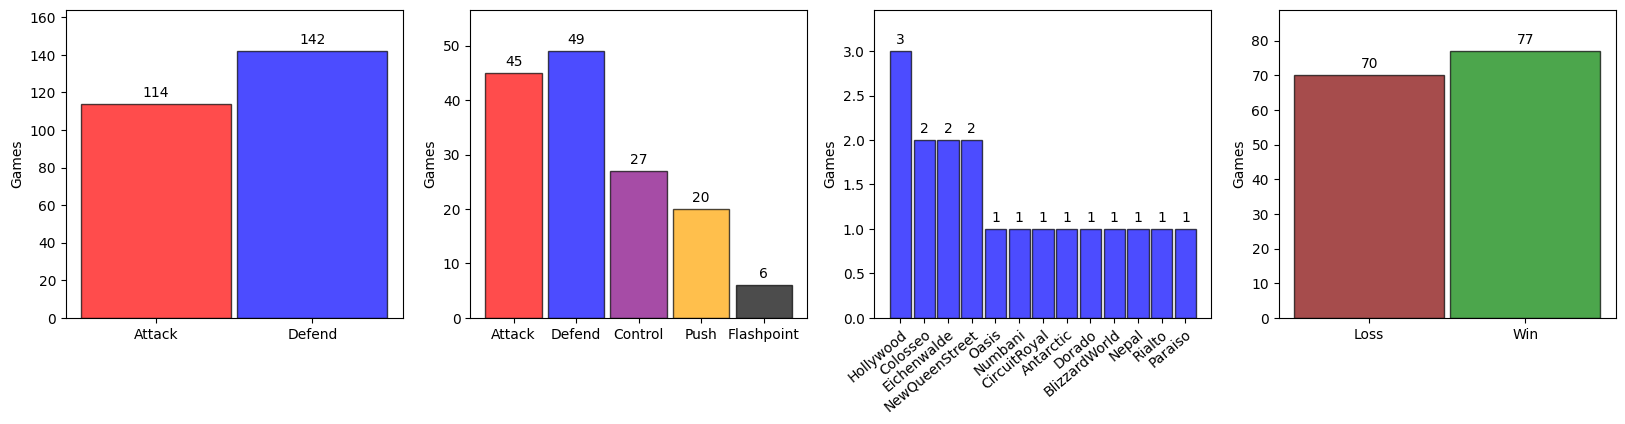

In [4]:
fig, axs = plt.subplots(1,4, figsize=(20,4))
DeffAtt = sb.histplot(data=df_OnlyDefAtt, x="MatchType", shrink=0.96, ax=axs[0])
FullMatchType = sb.histplot(data=df_Extended, x="MatchType", shrink=0.9, ax=axs[1])
FullMapType = sb.histplot(data=df_WithMaps, x="Map", shrink=0.9, ax=axs[2], color="blue")
WinLoss = sb.histplot(data=df, x="WinLoss", shrink=0.96, ax=axs[3])

alpha = 0.7

#Do some nicer colours
axs[0].patches[0].set_facecolor("red")
axs[0].patches[1].set_facecolor("blue")

axs[1].patches[0].set_facecolor("red")
axs[1].patches[1].set_facecolor("blue")
axs[1].patches[2].set_facecolor("purple")
axs[1].patches[3].set_facecolor("orange")
axs[1].patches[4].set_facecolor("black")

axs[3].patches[0].set_facecolor("maroon")
axs[3].patches[1].set_facecolor("green")

#Fix the tick labels for the map names
axs[2].xaxis.set_ticks(range(0,len(maps_ordered_by_plays)), labels=maps_ordered_by_plays,rotation=40, ha="right",rotation_mode='anchor')

for a in axs:
    a.set(ylabel="Games", ylim=(0,a.get_ylim()[1]*1.1))
    a.set(xlabel="")
    for p in a.patches:
        p.set_alpha(alpha)
    for container in a.containers:
        a.bar_label(container, padding=3)


## Now calculate some Win/Loss ratios to look for correlations

In [5]:
#Split the data different ways for different plots
#Winloss split by Map and MatchType
winloss_Map_MT_pivot = (
    df_WithMaps.pivot_table(index=["Map"], columns=["MatchType"], values="WinLoss_int", aggfunc='mean')
)
#Winloss split by GameMode and Matchtype
winloss_GM_MT_pivot = (
    df_Extended.pivot_table(index=["GameMode"], columns=["MatchType"], values="WinLoss_int", aggfunc='mean')
)
#Winloss split by just GameMode
winloss_GM_pivot = (
    df_Extended.pivot_table(index=["GameMode"], values="WinLoss_int", aggfunc='mean')
)
#Winloss split by just Map
winloss_Map_pivot = (
    df_WithMaps.pivot_table(index=["Map"], values="WinLoss_int", aggfunc='mean')
)
#Winloss split by play session
winloss_Session_pivot = (
    df_Extended.pivot_table(index=["SessionNumber"], values="WinLoss_int", aggfunc='mean')
)

#Pivot tables don't work well for multi-layered plots, use them to rebuild new dataframes
standard_gamemodes = ["Mystery","SixVSix"]
winloss_Map_MT_data = {"Map":[],"MatchType":[],"WinLoss":[]}
winloss_GM_MT_data = {"GameMode":[],"MatchType":[],"WinLoss":[]}
winloss_GM_MT_NoSpecial_data = [] #Remove ay non-standard gamemodes
winloss_GM_data = {"GameMode":[],"WinLoss":[]}
winloss_Map_data = {"Map":[],"WinLoss":[]}
winloss_Session_data = {"SessionNumber":[],"WinLoss":[]}

# Map and MatchType
for i in winloss_Map_MT_pivot.index:
    for k in winloss_Map_MT_pivot.keys():
        if (winloss_Map_MT_pivot[k][i] > 0): #don't bother including impossible combinations
            winloss_Map_MT_data["Map"].append(i)
            winloss_Map_MT_data["MatchType"].append(k)
            winloss_Map_MT_data["WinLoss"].append(winloss_Map_MT_pivot[k][i])
winloss_Map_MT = pd.DataFrame(winloss_Map_MT_data)

# GameMode and MatchType
for i in winloss_GM_MT_pivot.index:
    for k in winloss_GM_MT_pivot.keys():
        winloss_GM_MT_data["GameMode"].append(i)
        winloss_GM_MT_data["MatchType"].append(k)
        winloss_GM_MT_data["WinLoss"].append(winloss_GM_MT_pivot[k][i])
        if str(i) in standard_gamemodes:
            winloss_GM_MT_NoSpecial_data.append(winloss_GM_MT_pivot[k][i])
#Also calculate for combined gamemodes            
for k in winloss_GM_MT_pivot.keys():
    winloss_GM_MT_data["GameMode"].append("Combined")
    winloss_GM_MT_data["MatchType"].append(k)
    winloss_GM_MT_data["WinLoss"].append(np.mean(winloss_GM_MT_pivot[k]))
    winloss_GM_MT_NoSpecial_data.append(np.mean(winloss_GM_MT_pivot[k][standard_gamemodes]))
winloss_GM_MT = pd.DataFrame(winloss_GM_MT_data)

#Recalculate combined for case without special gamemodes
winloss_GM_MT_NoSpecial = winloss_GM_MT[winloss_GM_MT["GameMode"].isin(standard_gamemodes+["Combined"])].copy()
winloss_GM_MT_NoSpecial["WinLoss"] = winloss_GM_MT_NoSpecial_data

#Just GameMode
for i in winloss_GM_pivot.index:
    for k in winloss_GM_pivot.keys():
        winloss_GM_data["GameMode"].append(i)
        winloss_GM_data["WinLoss"].append(winloss_GM_pivot[k][i])
winloss_GM = pd.DataFrame(winloss_GM_data)

#Just Map
for i in winloss_Map_pivot.index:
    for k in winloss_Map_pivot.keys():
        winloss_Map_data["Map"].append(i)
        winloss_Map_data["WinLoss"].append(winloss_Map_pivot[k][i])
winloss_Map = pd.DataFrame(winloss_Map_data)

#Just session
for i in winloss_Session_pivot.index:
    for k in winloss_Session_pivot.keys():
        winloss_Session_data["SessionNumber"].append(int(i))
        winloss_Session_data["WinLoss"].append(winloss_Session_pivot[k][i])
winloss_Session = pd.DataFrame(winloss_Session_data)

#Sanity check the data
for d in [winloss_Map_MT,winloss_GM_MT,winloss_GM_MT_NoSpecial,winloss_GM,winloss_Map,winloss_Session]:
    print(d[0:2])
    print()


         Map MatchType  WinLoss
0  Hollywood    Attack      1.0
1  Hollywood    Defend      1.0

  GameMode MatchType   WinLoss
0  Mystery    Attack  0.454545
1  Mystery   Control  0.500000

  GameMode MatchType   WinLoss
0  Mystery    Attack  0.454545
1  Mystery   Control  0.500000

  GameMode   WinLoss
0  Mystery  0.493151
1  SixVSix  0.546875

         Map  WinLoss
0  Hollywood      1.0
1   Colosseo      0.0

   SessionNumber   WinLoss
0              1  0.222222
1              2  0.300000



## Plot breakdowns by GameMode and Play session

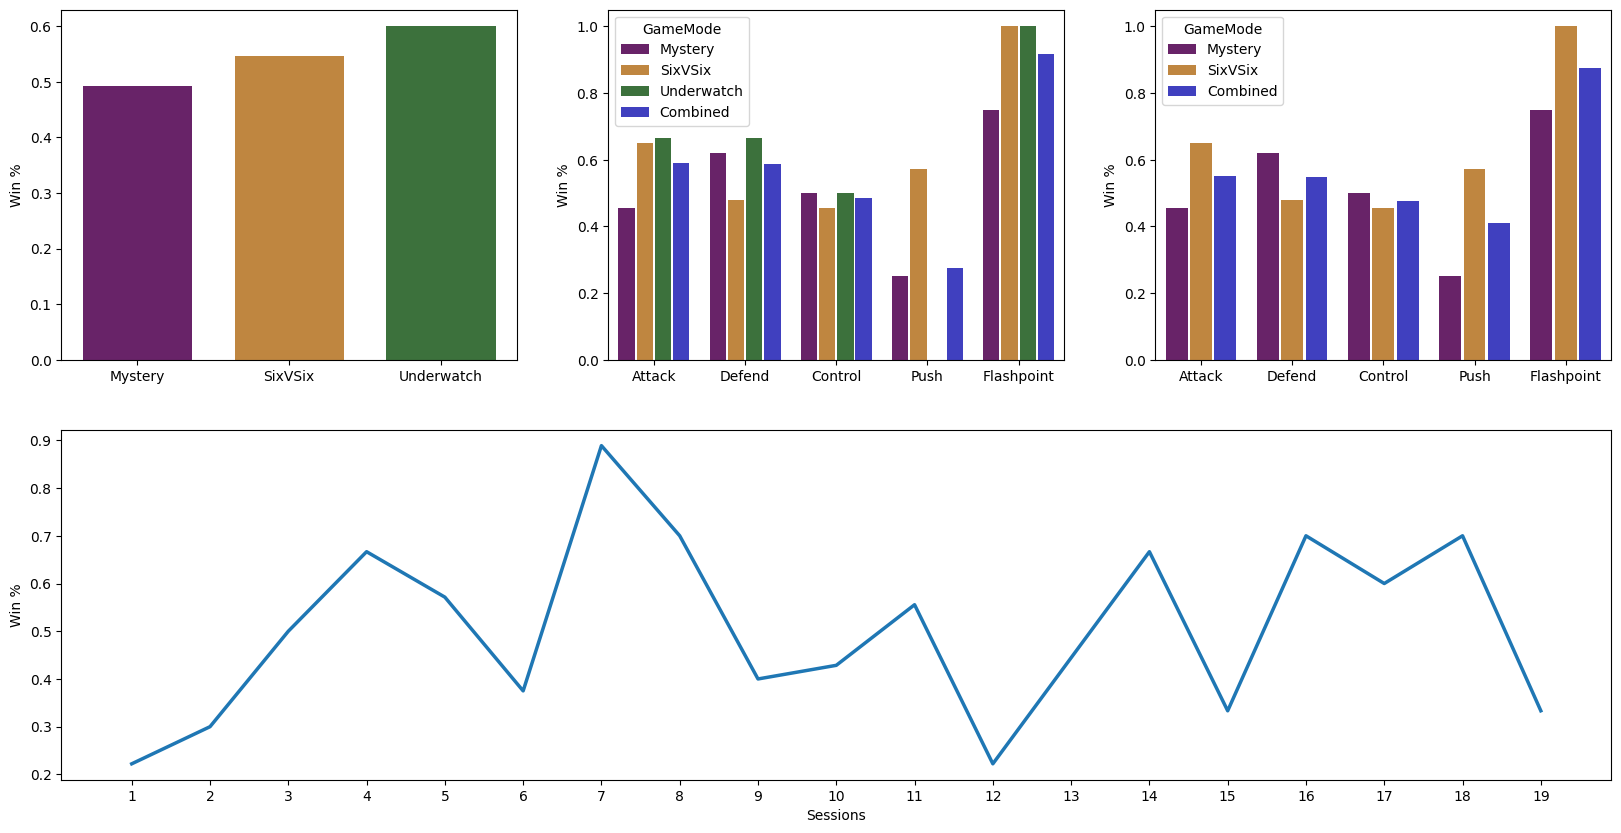

In [6]:
fig = plt.figure(figsize=(20,10))
gs = fig.add_gridspec(2, 3)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :]) # Spans all columns in row 2

WLR_by_GM = sb.barplot(data=winloss_GM, x="GameMode", y="WinLoss", hue="GameMode", palette=["darkmagenta","darkorange","forestgreen"], legend=False,
                               order=["Mystery","SixVSix","Underwatch"],saturation=0.5, gap=0.1, ax=ax1)

WLR_by_GM_MT = sb.barplot(data=winloss_GM_MT, x="MatchType", y="WinLoss", hue="GameMode", palette=["darkmagenta","darkorange","forestgreen","blue"], 
                               order=["Attack","Defend","Control","Push","Flashpoint"],saturation=0.5, gap=0.1, ax=ax2)

WLR_by_GM_MT_NoSpecial = sb.barplot(data=winloss_GM_MT_NoSpecial, x="MatchType", y="WinLoss", hue="GameMode", palette=["darkmagenta","darkorange","blue"],
                                order=["Attack","Defend","Control","Push","Flashpoint"], saturation=0.5, gap=0.1, ax=ax3)
WLR_by_Session = sb.lineplot(data=winloss_Session, x="SessionNumber", y="WinLoss", ax=ax4, lw=2.5)

for a in [ax1,ax2,ax3,ax4]:
    a.set(ylabel="Win %")
    a.set(xlabel="")
ax4.set(xlabel="Sessions")
ax4.xaxis.set_ticks(range(1,len(winloss_Session)+1),labels=winloss_Session["SessionNumber"])
print()

## Plot breakdowns by Maps

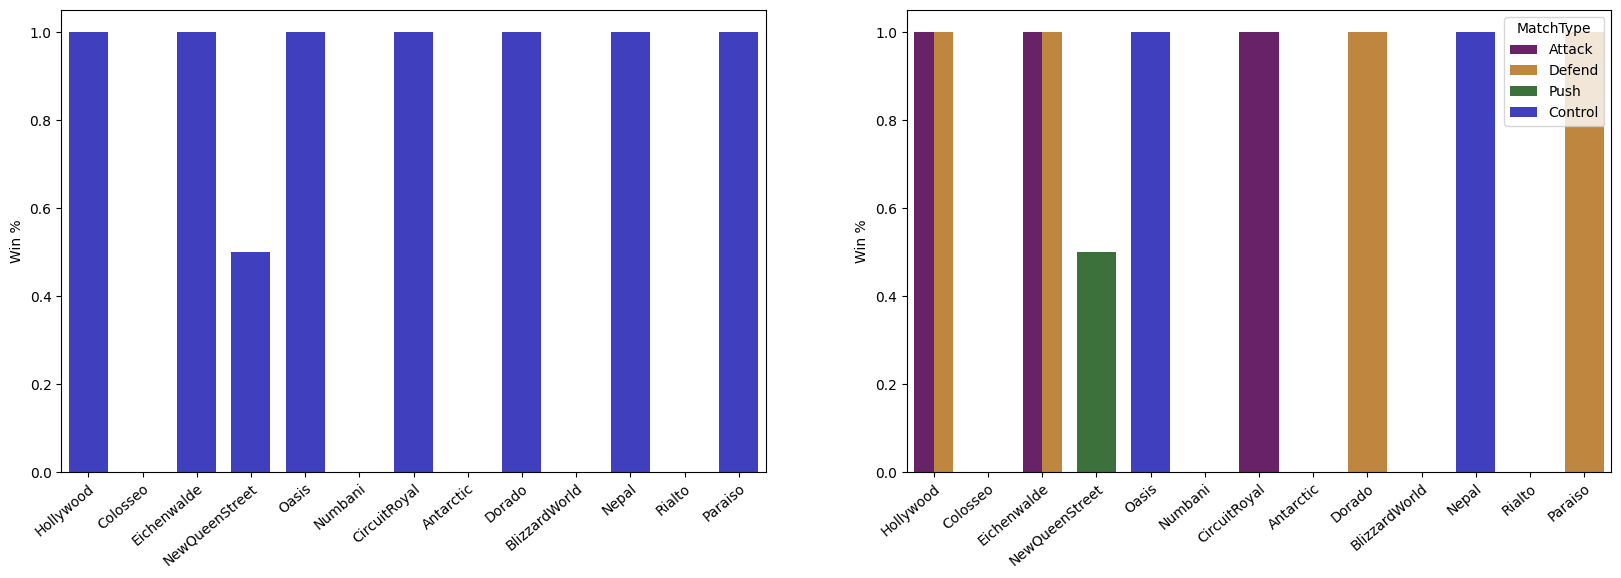

In [7]:

fig = plt.figure(figsize=(20,6))
gs = fig.add_gridspec(1, 2)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1])

WLR_by_Map = sb.barplot(data=winloss_Map, x="Map", y="WinLoss", color="blue", legend=False,
                               order=maps_ordered_by_plays,saturation=0.5, gap=0.1, ax=ax1)

WLR_by_Map_MT = sb.barplot(data=winloss_Map_MT, x="Map", y="WinLoss", hue="MatchType", palette=["darkmagenta","darkorange","forestgreen","blue"], 
                           order=maps_ordered_by_plays, saturation=0.5, gap=0.1, ax=ax2, dodge=False)

for a in [ax1,ax2]:
    a.set(ylabel="Win %")
    a.set(xlabel="")
    a.xaxis.set_ticks(range(0,len(maps_ordered_by_plays)),labels=maps_ordered_by_plays,rotation=40, ha="right",rotation_mode='anchor')

#Hack to seperate out attack and defend at the axis level
#First remove any 0 width patches
for p in ax2.patches:
    if p.get_width() == 0:
        p.remove()

for p in ax2.patches:
    n_copies=0
    for pp in ax2.patches:
        if (p.get_x() == pp.get_x()):
            if n_copies>0:
                p.set_width(p.get_width()/2.0)
                pp.set_width(pp.get_width()/2.0)
                pp.set_x(pp.get_x()+p.get_width())
            else:
                n_copies += 1


## Now calculate Defend/Attack ratios to see if these correlate with Win/Loss

In [8]:
df_WithMaps_AttDef = df_WithMaps[(df_WithMaps['MatchType'] == "Attack") | (df_WithMaps['MatchType'] == "Defend")].copy()

#Defend% split by Map
attdef_Map_pivot = (
    df_WithMaps_AttDef.pivot_table(index=["Map"], values="MatchType_int", aggfunc='mean')
)
#Defend% split by GameMode
attdef_GM_pivot = (
    df_OnlyDefAtt.pivot_table(index=["GameMode"], values="MatchType_int", aggfunc='mean')
)
#Defend% split by play session
attdef_Session_pivot = (
    df_Extended.pivot_table(index=["SessionNumber"], values="MatchType_int", aggfunc='mean')
)

#Pivot tables don't work well for multi-layered plots, use them to rebuild new dataframe
attdef_Map_data = {"Map":[],"Att/Def":[]}
attdef_GM_data = {"GameMode":[],"Att/Def":[]}
attdef_Session_data = {"SessionNumber":[],"Att/Def":[]}

for i in attdef_Map_pivot.index:
    for k in attdef_Map_pivot.keys():
        attdef_Map_data["Map"].append(i)
        attdef_Map_data["Att/Def"].append(attdef_Map_pivot[k][i])
attdef_Map = pd.DataFrame(attdef_Map_data)

for i in attdef_GM_pivot.index:
    for k in attdef_GM_pivot.keys():
        attdef_GM_data["GameMode"].append(i)
        attdef_GM_data["Att/Def"].append(attdef_GM_pivot[k][i])
for k in attdef_GM_pivot.keys():
    attdef_GM_data["GameMode"].append("Combined")
    attdef_GM_data["Att/Def"].append(np.mean(attdef_GM_pivot[k]))
attdef_GM = pd.DataFrame(attdef_GM_data)

for i in attdef_Session_pivot.index:
    for k in attdef_Session_pivot.keys():
        attdef_Session_data["SessionNumber"].append(int(i))
        attdef_Session_data["Att/Def"].append(attdef_Session_pivot[k][i])
attdef_Session_data["WinLoss"] = winloss_Session_data["WinLoss"].copy() #Also add the Win/Loss to compare
attdef_Session = pd.DataFrame(attdef_Session_data)

#Sanity check the data
for d in [attdef_Map,attdef_GM,attdef_Session]:
    print(d[0:3])
    print()


           Map   Att/Def
0    Hollywood  0.666667
1  Eichenwalde  0.500000
2      Numbani  0.000000

     GameMode   Att/Def
0     Mystery  0.488372
1     SixVSix  0.555556
2  Underwatch  0.500000

   SessionNumber   Att/Def   WinLoss
0              1  0.222222  0.222222
1              2  0.300000  0.300000
2              3  0.500000  0.500000



## Lastly plot Defence% breakdowns and compare to Win/Loss over time

Text(0, 0.5, 'Defend %')

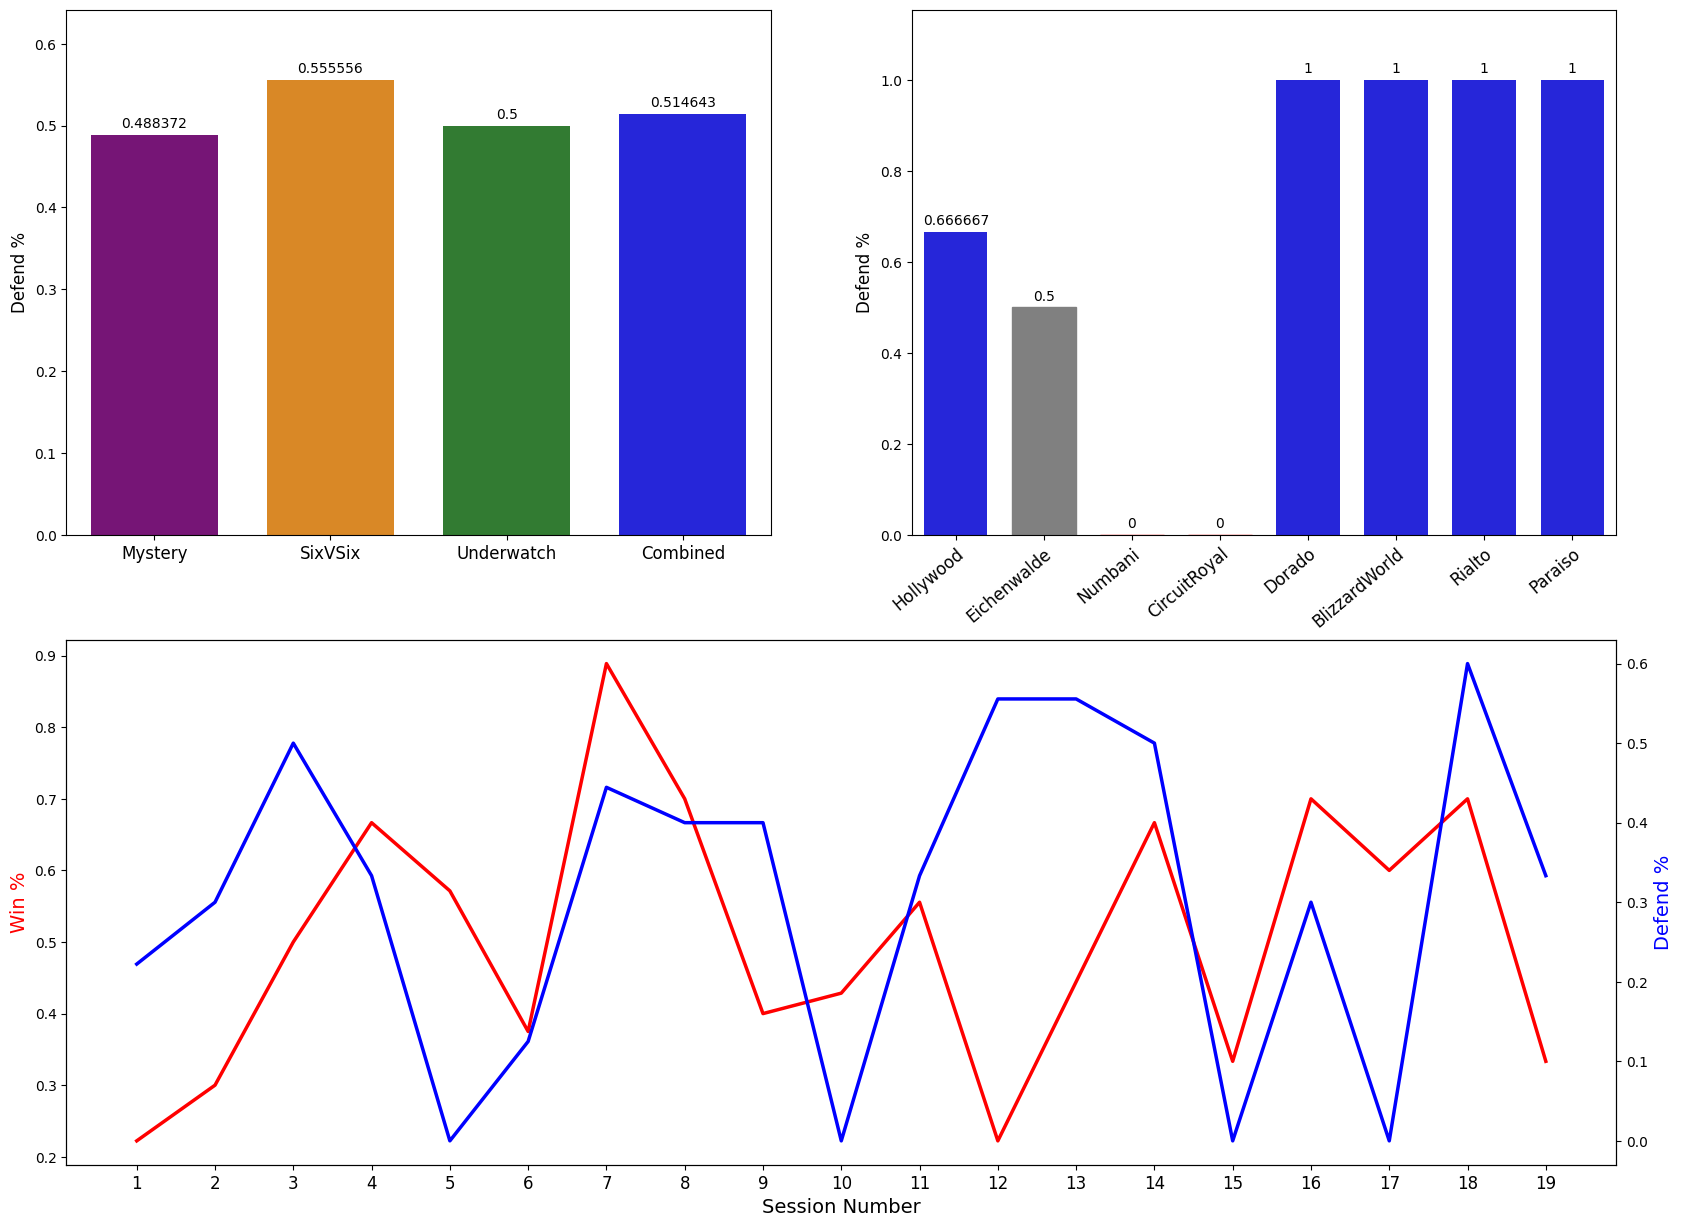

In [9]:

fig = plt.figure(figsize=(20,15))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0]) 
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :]) #Spans both columns in row 1

#Defend% by gamemode and map
ADR_by_GM = sb.barplot(data=attdef_GM, x="GameMode",  y="Att/Def", hue="GameMode", palette=["darkmagenta","darkorange","forestgreen","blue"], legend=False, 
                       order=["Mystery","SixVSix","Underwatch","Combined"], saturation=0.7, gap=0.1, ax=ax1)
ADR_by_Map = sb.barplot(data=attdef_Map, x="Map",  y="Att/Def", color="blue", saturation=0.7, gap=0.1, ax=ax2)
for a in [ax1,ax2]:
        a.set_ylabel("Defend %", fontsize=12)
        a.set_ylim(0,a.get_ylim()[1]*1.1)
        a.set_xlabel("")
ax1.xaxis.set_ticks(range(0,len(ax1.get_xticklabels())),labels=ax1.get_xticklabels(),fontsize=12)
ax2.xaxis.set_ticks(range(0,len(ax2.get_xticklabels())),labels=ax2.get_xticklabels(),rotation=40, ha="right",rotation_mode='anchor',fontsize=12)
for p in ax2.patches:
      if p.get_height() < 0.5:
            p.set_color("red")
      elif p.get_height() == 0.5:
            p.set_color("grey")
for container in ax1.containers:
    ax1.bar_label(container, padding=3)
for container in ax2.containers:
    ax2.bar_label(container, padding=3)

#Defend% and Win% over time to check correlation         
WLR_by_Session = sb.lineplot(data=attdef_Session, x="SessionNumber", y="WinLoss", ax=ax3, lw=2.5, color='red', label='')
ax3.set_ylabel('Win %', color='red', fontsize=14)
ax3.set_xlabel('Session Number', color='black', fontsize=14)
ax3.xaxis.set_ticks(range(1,len(attdef_Session)+1),labels=attdef_Session["SessionNumber"],fontsize=12)

ax4 = ax3.twinx()
ADR_by_Session = sb.lineplot(data=attdef_Session, x="SessionNumber", y="Att/Def", ax=ax4, lw=2.5, color='blue', label='')
ax4.set_ylabel('Defend %', color='blue', fontsize=14)